# Real E-Commerce Sales Analysis
**Dataset source : Kaggle — International Sales Report**
7,800 real transactions from 2021 to 2022

In [1]:
import sys
import os
sys.path.insert(0, r'C:\Users\pc\Desktop\data_project\src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from preprocessing import (
    load_data, clean_data, create_time_features,
    calculate_metrics, segment_customers, prepare_ml_data, display_summary
)
from model import SalesPredictor

# Load real dataset
DATA_PATH = r'C:\Users\pc\Desktop\data_project\data\dataset_real.csv'
data = load_data(DATA_PATH)
data = clean_data(data)
data = create_time_features(data)
data = calculate_metrics(data)

# Train model
X, y, feature_names = prepare_ml_data(data)
predictor = SalesPredictor(algorithm='gradient_boosting')
predictor.train(X, y, feature_names=feature_names)

print("\nEverything is ready!")

[OK] Dataset loaded: 7,799 rows, 14 columns
[OK] Cleaning done: 6,978 rows kept (821 removed)
[OK] Time features created
[OK] Business metrics calculated

[ML] ML data ready - X: (6978, 4), y: (6978,) | features: ['Prix_Unitaire', 'Quantite', 'Mois_Num', 'Jour_Semaine']
[OK] Model trained (gradient_boosting)
   R2 train : 0.9971
   R2 test  : 0.9927
   RMSE     : 49.77 EUR

Everything is ready!


## 1. Business Summary

In [2]:
display_summary(data)


[STAT] BUSINESS SUMMARY - REAL DATASET
  [SHOP] Transactions      : 6,978
  [>>]  Unique customers   : 59
  [PKG] Unique products    : 690

  [EUR] Total revenue      :   5,584,334.00
  [STAT] Avg per transaction:        800.28
  [UP]  Total profit       :   2,417,888.25
  [ROI] Avg margin         :         43.46 %

  [TOP] Top category       : Robe/Jupe
  [TOP] Top customer       : COTTON CLOSET LTD


## 2. Revenue by Category

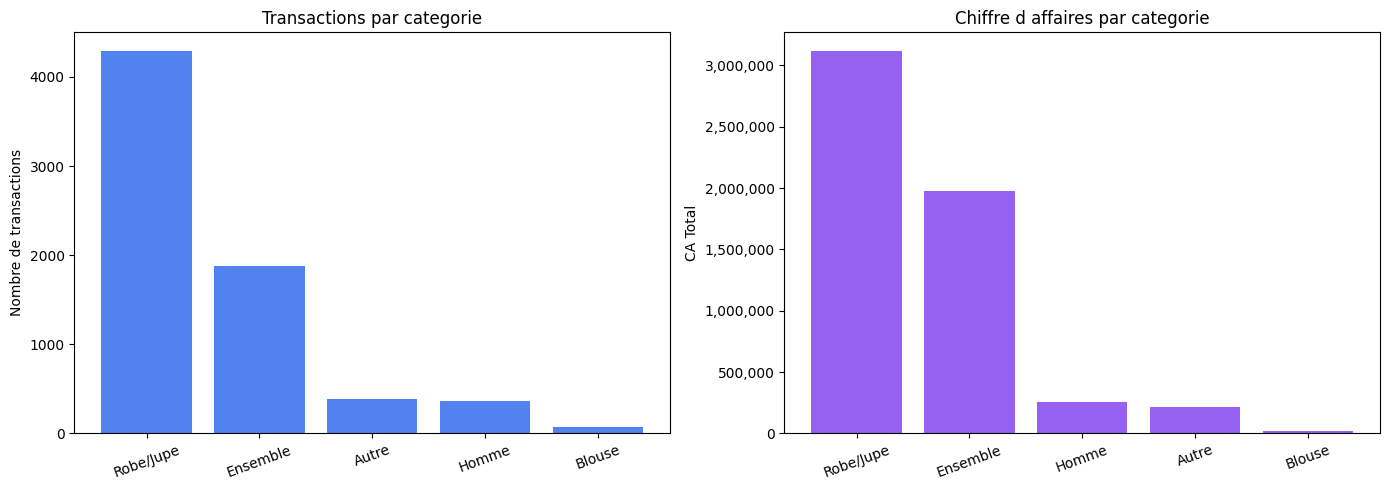

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transactions per category
cat_counts = data['Categorie'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values, color='#2563EB', alpha=0.8)
axes[0].set_title('Transactions par categorie')
axes[0].set_ylabel('Nombre de transactions')
axes[0].tick_params(axis='x', rotation=20)

# Revenue per category
cat_rev = data.groupby('Categorie')['CA'].sum().sort_values(ascending=False)
axes[1].bar(cat_rev.index, cat_rev.values, color='#7C3AED', alpha=0.8)
axes[1].set_title('Chiffre d affaires par categorie')
axes[1].set_ylabel('CA Total')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 3. Monthly Revenue Evolution

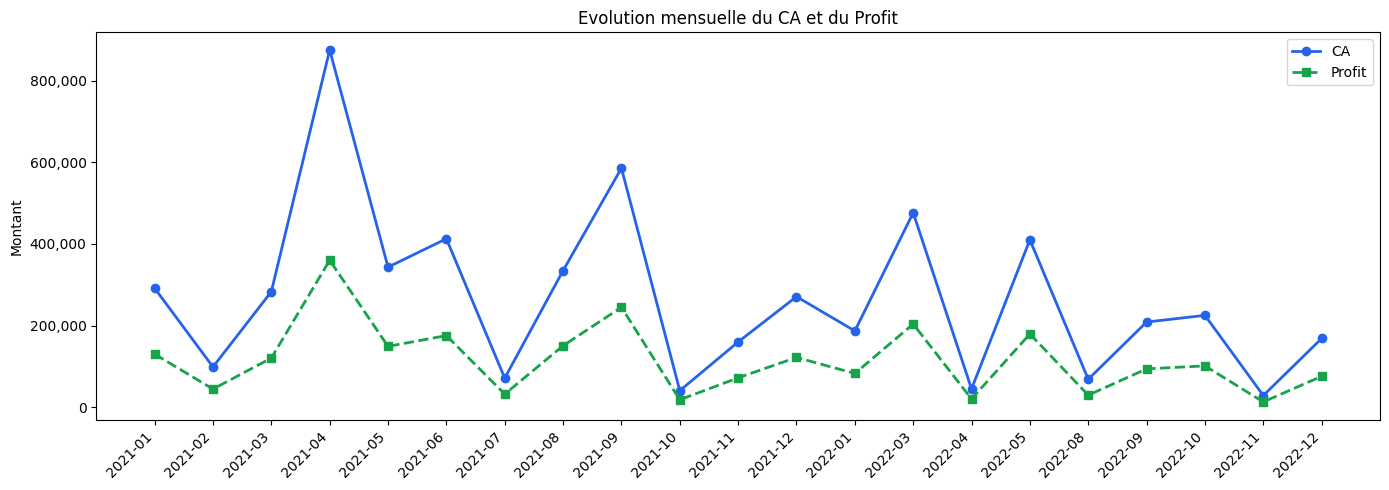

In [4]:
monthly = data.groupby(['Annee', 'Mois_Num']).agg(
    CA=('CA', 'sum'),
    Profit=('Profit', 'sum'),
    Transactions=('Transaction_ID', 'count')
).reset_index()
monthly['Period'] = monthly['Annee'].astype(str) + '-' + monthly['Mois_Num'].astype(str).str.zfill(2)
monthly = monthly.sort_values('Period')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Period'], monthly['CA'], marker='o', linewidth=2,
        color='#2563EB', label='CA')
ax.plot(monthly['Period'], monthly['Profit'], marker='s', linewidth=2,
        color='#16A34A', linestyle='--', label='Profit')
ax.set_title('Evolution mensuelle du CA et du Profit')
ax.set_ylabel('Montant')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Top 10 Customers by Revenue

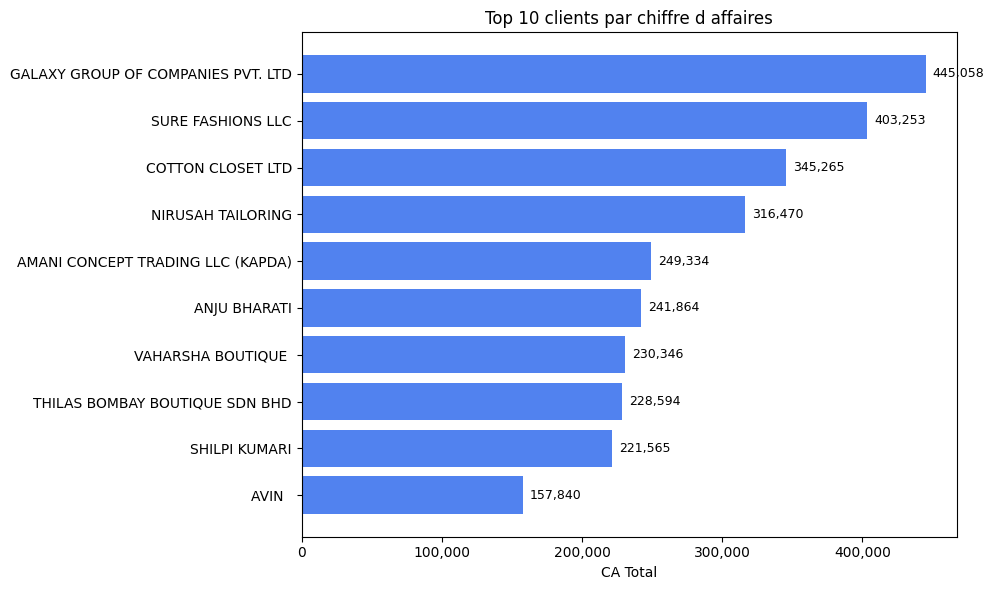

In [5]:
top_customers = data.groupby('Customer_ID')['CA'].sum().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_customers.index, top_customers.values, color='#2563EB', alpha=0.8)
ax.set_title('Top 10 clients par chiffre d affaires')
ax.set_xlabel('CA Total')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, top_customers.values):
    ax.text(val + 5000, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Customer Segmentation RFM


[>>] CUSTOMER SEGMENTATION
Segment
VIP         33
Regulier    26


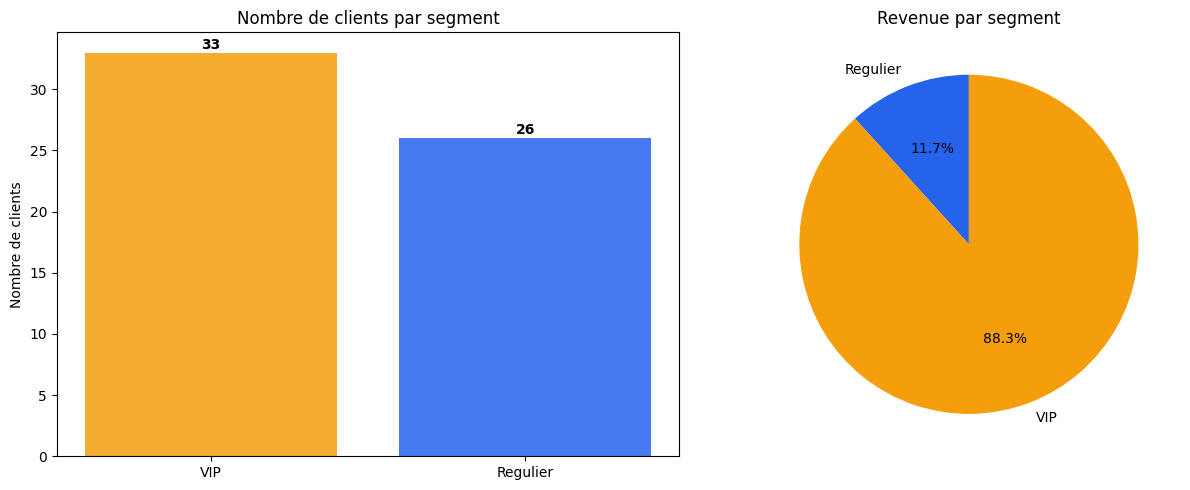


Stats par segment:
          Frequence  Montant_Total  Quantite_Totale
Segment                                            
Regulier      37.31       25153.42            39.27
VIP          182.06      149404.39           242.06


In [6]:
customers = segment_customers(data)

seg_counts = customers['Segment'].value_counts()
colors_map = {'VIP': '#F59E0B', 'Regulier': '#2563EB', 'Occasionnel': '#6B7280'}
bar_colors = [colors_map.get(s, 'gray') for s in seg_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(seg_counts.index, seg_counts.values, color=bar_colors, alpha=0.85)
axes[0].set_title('Nombre de clients par segment')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

seg_revenue = customers.groupby('Segment')['Montant_Total'].sum()
axes[1].pie(seg_revenue.values, labels=seg_revenue.index,
            colors=[colors_map.get(s, 'gray') for s in seg_revenue.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Revenue par segment')

plt.tight_layout()
plt.show()

print("\nStats par segment:")
print(customers.groupby('Segment')[['Frequence','Montant_Total','Quantite_Totale']].mean().round(2))

## 6. Price Distribution by Category

C:\Users\pc\AppData\Local\Temp\ipykernel_21524\128220909.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_cat, labels=categories, patch_artist=True,


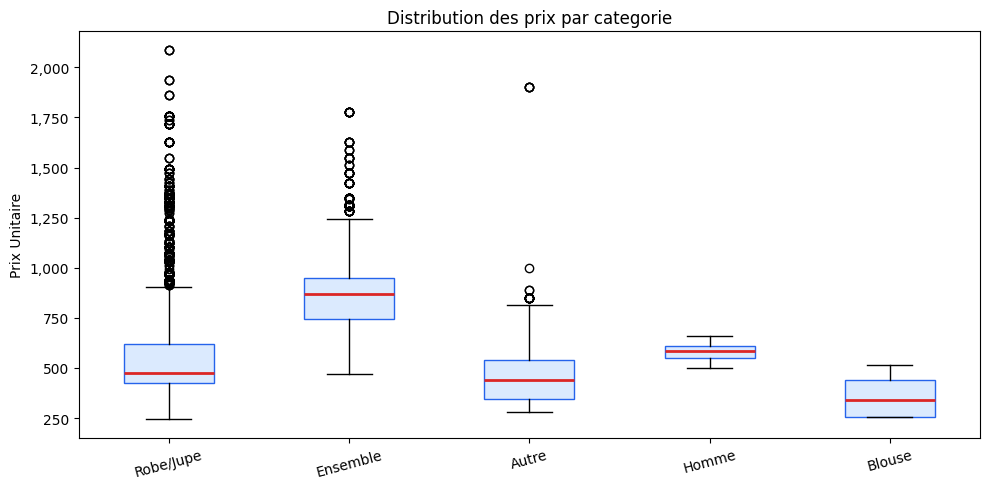

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
categories = data['Categorie'].unique()
data_by_cat = [data[data['Categorie'] == cat]['Prix_Unitaire'].values for cat in categories]
ax.boxplot(data_by_cat, labels=categories, patch_artist=True,
           boxprops=dict(facecolor='#DBEAFE', color='#2563EB'),
           medianprops=dict(color='#DC2626', linewidth=2))
ax.set_title('Distribution des prix par categorie')
ax.set_ylabel('Prix Unitaire')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 7. ML Model - Feature Importance

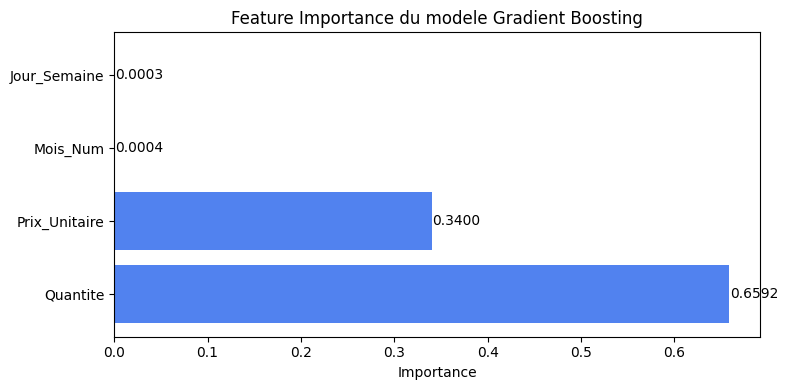


Metriques du modele:
  algorithm: gradient_boosting
  r2_train: 0.9971
  r2_test: 0.9927
  rmse_test: 49.77


In [8]:
importance = predictor.get_feature_importance()
names = list(importance.keys())
values = list(importance.values())

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(names, values, color='#2563EB', alpha=0.8)
ax.set_title('Feature Importance du modele Gradient Boosting')
ax.set_xlabel('Importance')
for bar, val in zip(bars, values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center')
plt.tight_layout()
plt.show()

print("\nMetriques du modele:")
for k, v in predictor.metrics.items():
    print(f"  {k}: {v}")

## 8. Revenue Predictions

 Prix_Unitaire  CA_Predit
           500     497.11
           750     730.44
          1000     980.66
          1500    1482.12
          2000    1941.71


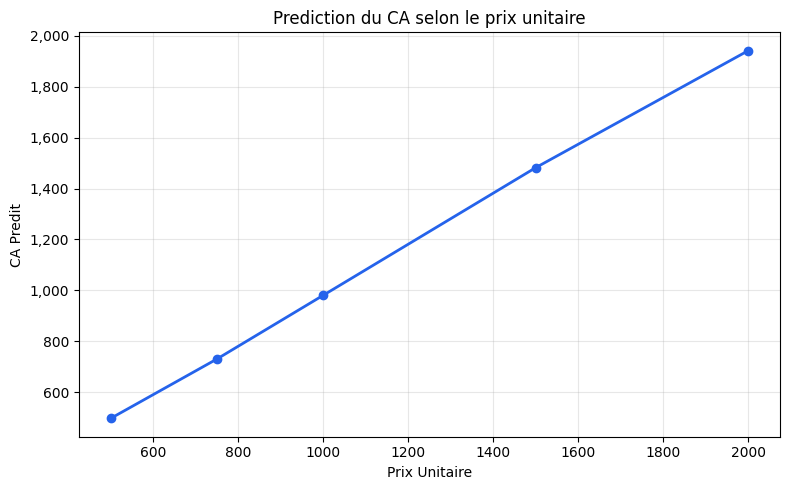

In [9]:
avg_quantite = data['Quantite'].mean()
avg_mois = data['Mois_Num'].mean()
avg_jour = data['Jour_Semaine'].mean()

prix_list = [500, 750, 1000, 1500, 2000]
predictions = []
for p in prix_list:
    X_input = np.array([[p, avg_quantite, avg_mois, avg_jour]])
    pred = predictor.model.predict(X_input)[0]
    predictions.append(round(float(pred), 2))

results = pd.DataFrame({
    'Prix_Unitaire': prix_list,
    'CA_Predit': predictions,
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(prix_list, predictions, marker='o', color='#2563EB', linewidth=2)
ax.set_title('Prediction du CA selon le prix unitaire')
ax.set_xlabel('Prix Unitaire')
ax.set_ylabel('CA Predit')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()